**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# Equipo 35

*   NOMBRE: Darío Martín Romero Cruz 
*   MATRÍCULA: A01841015

______________________________________

*   NOMBRE: Erick Rojas Perez
*   MATRÍCULA: A01840850

______________________________________

*   NOMBRE: Julio Arath Rosales Oliden 
*   MATRÍCULA: A01630378

______________________________________

*   NOMBRE: Manuel Ruiz Diaz de Rivera
*   MATRÍCULA: A01325485

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [2]:
# Instalar las bibliotecas necesarias
#%pip install category_encoders

In [3]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
import warnings
# Se ocultan warnings tras verificar que no afectan los resultados (p. ej. avisos de versiones de seaborn/sklearn).
#warnings.filterwarnings('ignore')

1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [4]:
# compu_df = pd.read_csv('/content/drive/MyDrive/MNA Master/CyAD/act6/computer_prices.csv')
compu_df=pd.read_csv('computer_prices.csv')
print(compu_df.info())
print(compu_df.nunique())
compu_df.drop(columns=['model', 'cpu_model'], inplace=True)
num_cols = compu_df.select_dtypes(include=np.number).columns
cat_cols = compu_df.select_dtypes(exclude=np.number).columns
print(f'Columnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

Hay 15 columnas numéricas y 10 categóricas (después de la eliminación)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

No hay valores faltantes, como nos indica el método .info() y las tablas de frecuencias de las variables categóricas.

Los valores en 0 para las variables **charger_watts** y **psu_watts** podrían ser considerados como faltantes.

In [5]:
compu_df[num_cols].describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.991350,6.152180,39.706400,903.936000,1.524980,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,1.459643,3.964926,31.902684,774.243654,0.797284,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,1.000000,0.000000,8.000000,256.000000,1.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.000000,4.000000,16.000000,512.000000,1.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,3.000000,6.000000,32.000000,512.000000,1.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,4.000000,8.000000,64.000000,1024.000000,2.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,6.000000,16.000000,144.000000,4096.000000,4.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [6]:
# Estadisticas descriptivas de las variables categoricas
compu_df[cat_cols].describe()

,device_type,brand,os,form_factor,cpu_brand,gpu_brand,gpu_model,storage_type,display_type,wifi
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,2,10,4,10,3,4,49,4,6,4
top,Laptop,Lenovo,Windows,Mainstream,Intel,NVIDIA,Apple Integrated,NVMe,LED,Wi-Fi 6
freq,59844,15992,71817,17819,52774,54712,18922,45059,32000,46149


In [7]:
print('Registros duplicados:', compu_df.duplicated().sum())
print('Valores faltantes totales:', compu_df.isna().sum().sum())


Registros duplicados: 0
Valores faltantes totales: 0


In [8]:
# Frecuencias
for col in cat_cols:
  display(compu_df[col].value_counts())

device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64

brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64

os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867
Name: count, dtype: int64

form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192
Name: count, dtype: int64

cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype: int64

gpu_brand
NVIDIA    54712
Apple     18922
AMD       15767
Intel     10599
Name: count, dtype: int64

gpu_model
Apple Integrated    18922
RTX 40 70            5743
RTX 30 70            5692
RTX 40 60            5437
RTX 30 60            5314
RTX 30 50            5046
RTX 40 50            4970
RTX 40 80            4676
RTX 30 80            4618
RTX 30 80 Ti         2752
RTX 40 80 Ti         2685
Arc A580             1947
Arc A310             1818
Arc A380             1817
RX 7000 70           1636
RX 6000 70           1620
Arc A700             1611
RX 6000 60           1608
RX 7000 60           1521
RX 7000 50           1404
RX 6000 50           1375
RX 7000 80           1349
RTX 20 70            1319
RX 6000 80           1293
RTX 20 60            1229
RTX 40 90            1137
RTX 30 90            1129
RTX 20 50            1120
RTX 20 80            1009
Arc A770              922
RX 6000 80 XT         823
RX 7000 80 XT         814
RTX 20 80 Ti          571
Arc B580              475
Arc B380              474
Arc B310              429
Arc A770 Limited      387
Arc B700              386
RX

storage_type
NVMe      45059
SSD       24937
HDD       15023
Hybrid    14981
Name: count, dtype: int64

display_type
LED         32000
OLED        21910
IPS         17742
Mini-LED    12188
QLED        10069
VA           6091
Name: count, dtype: int64

wifi
Wi-Fi 6     46149
Wi-Fi 6E    25923
Wi-Fi 5     19926
Wi-Fi 7      8002
Name: count, dtype: int64

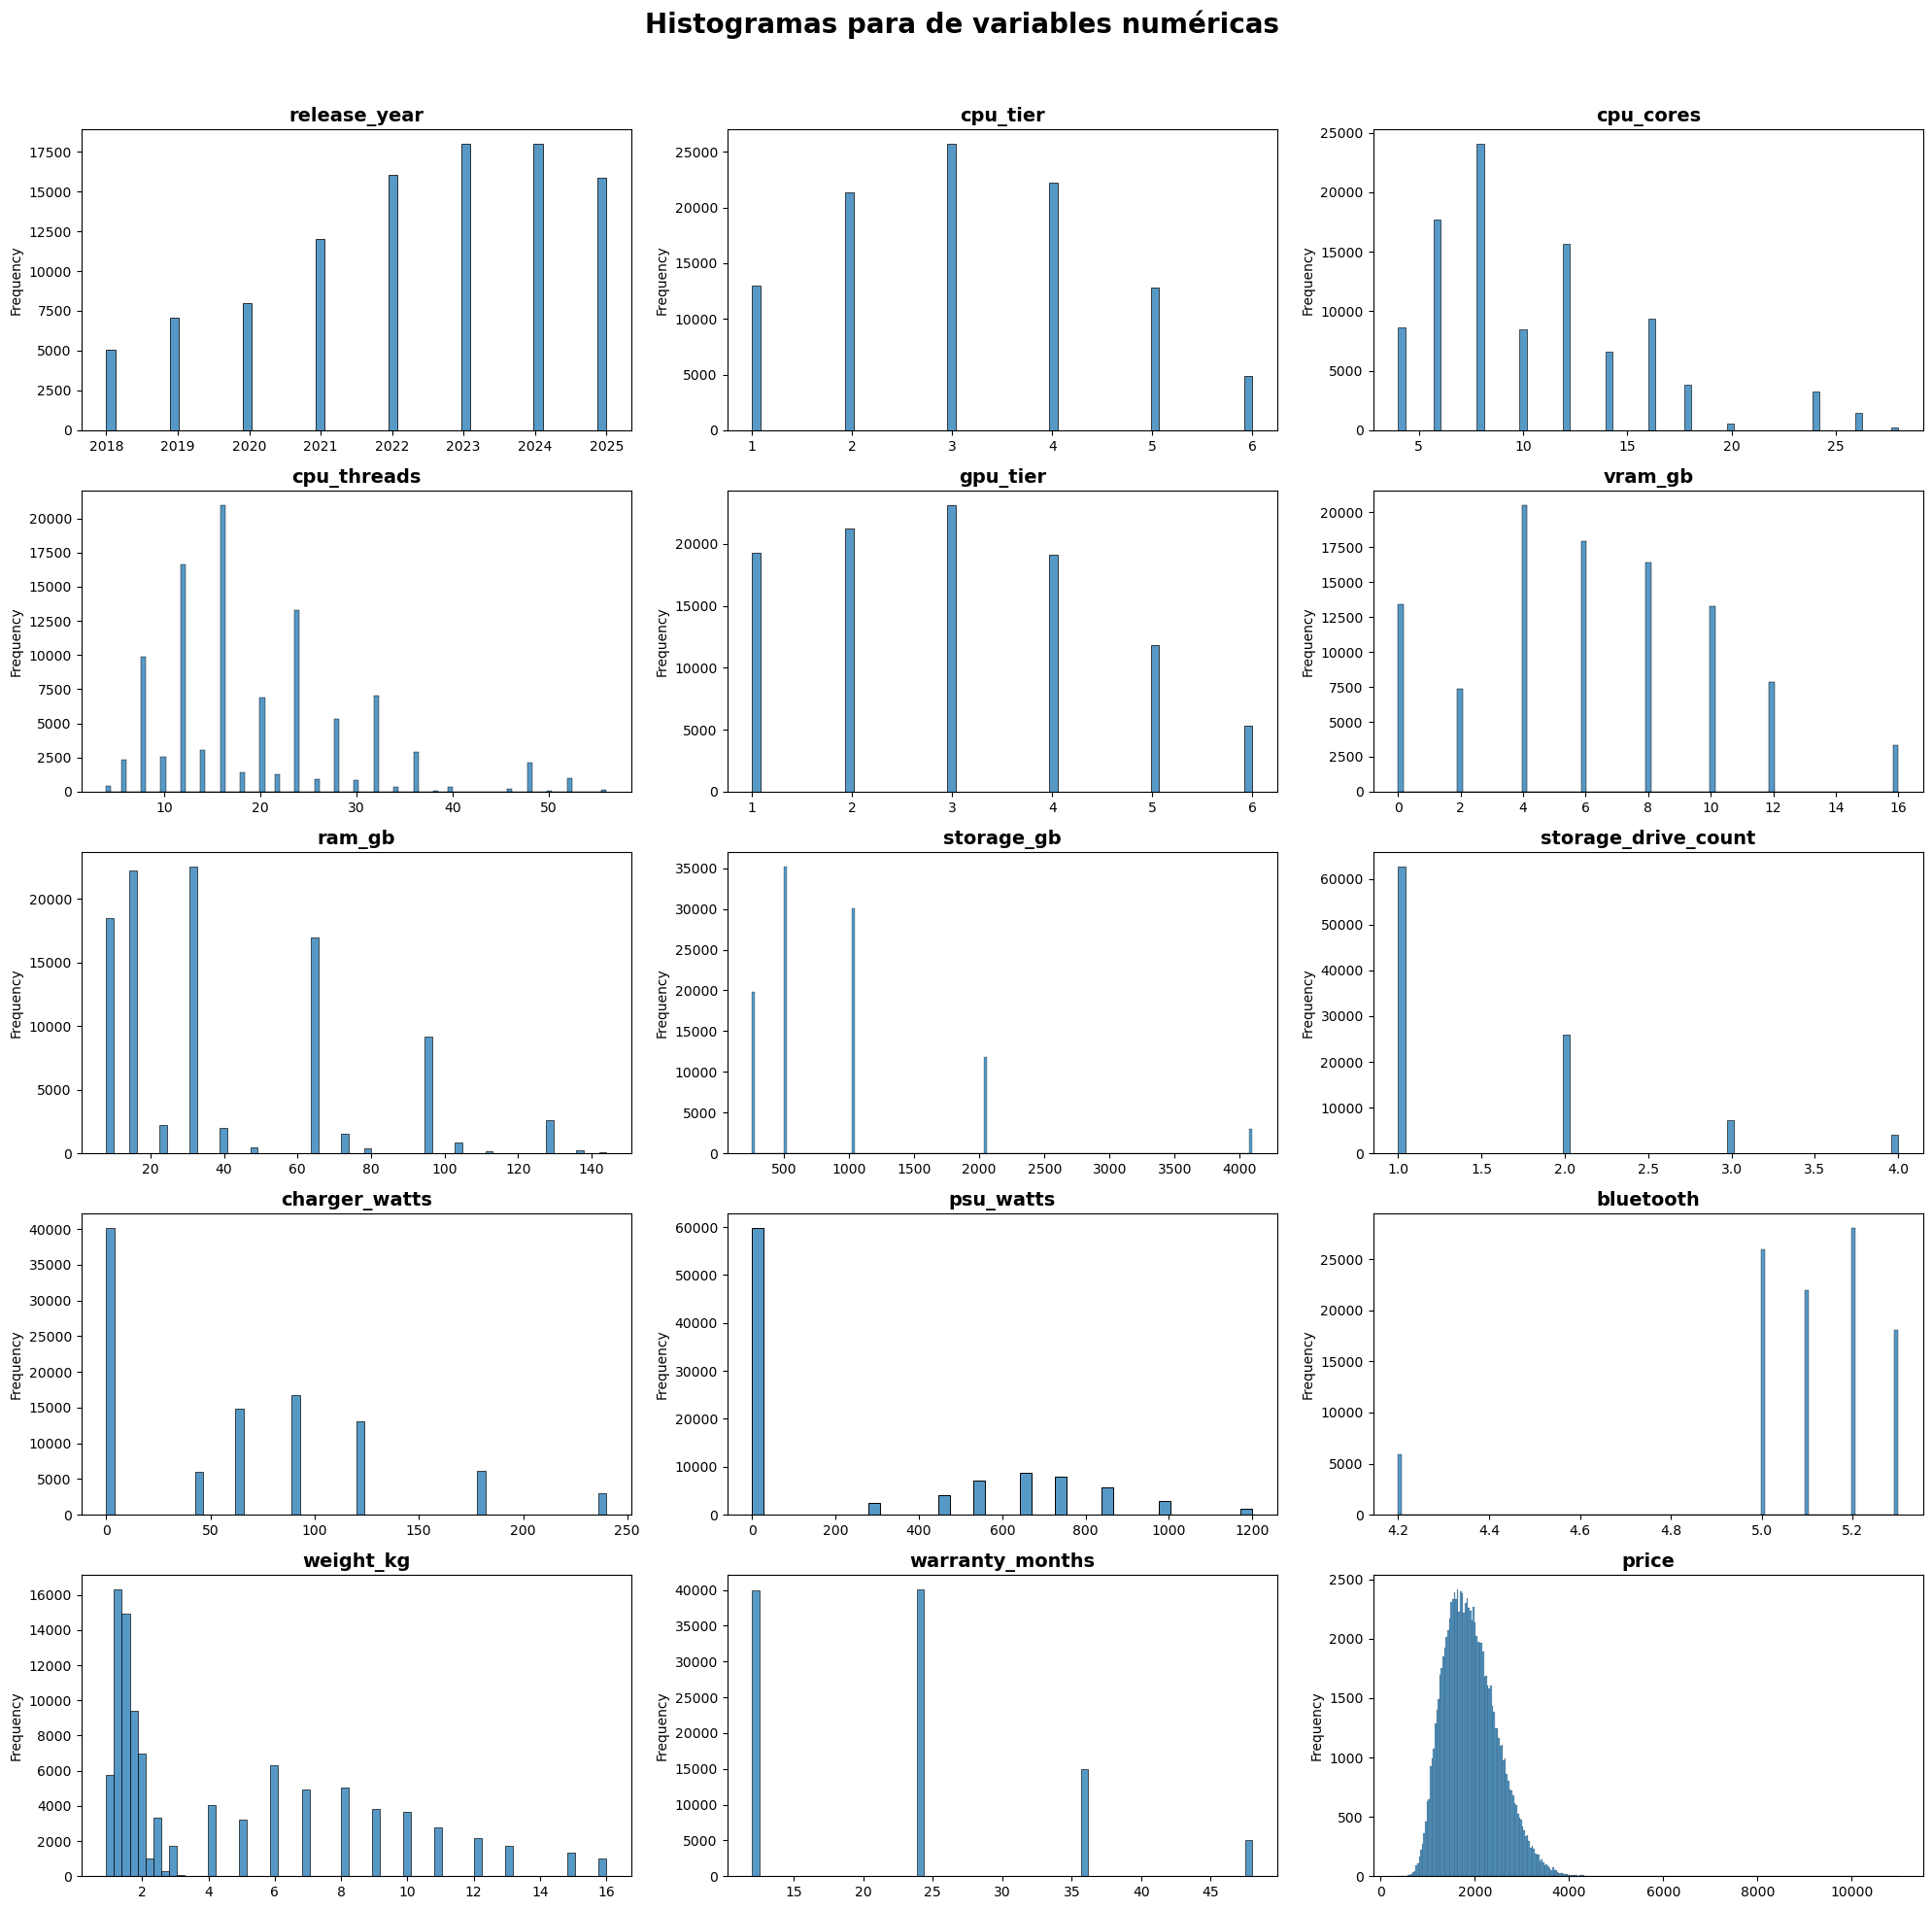

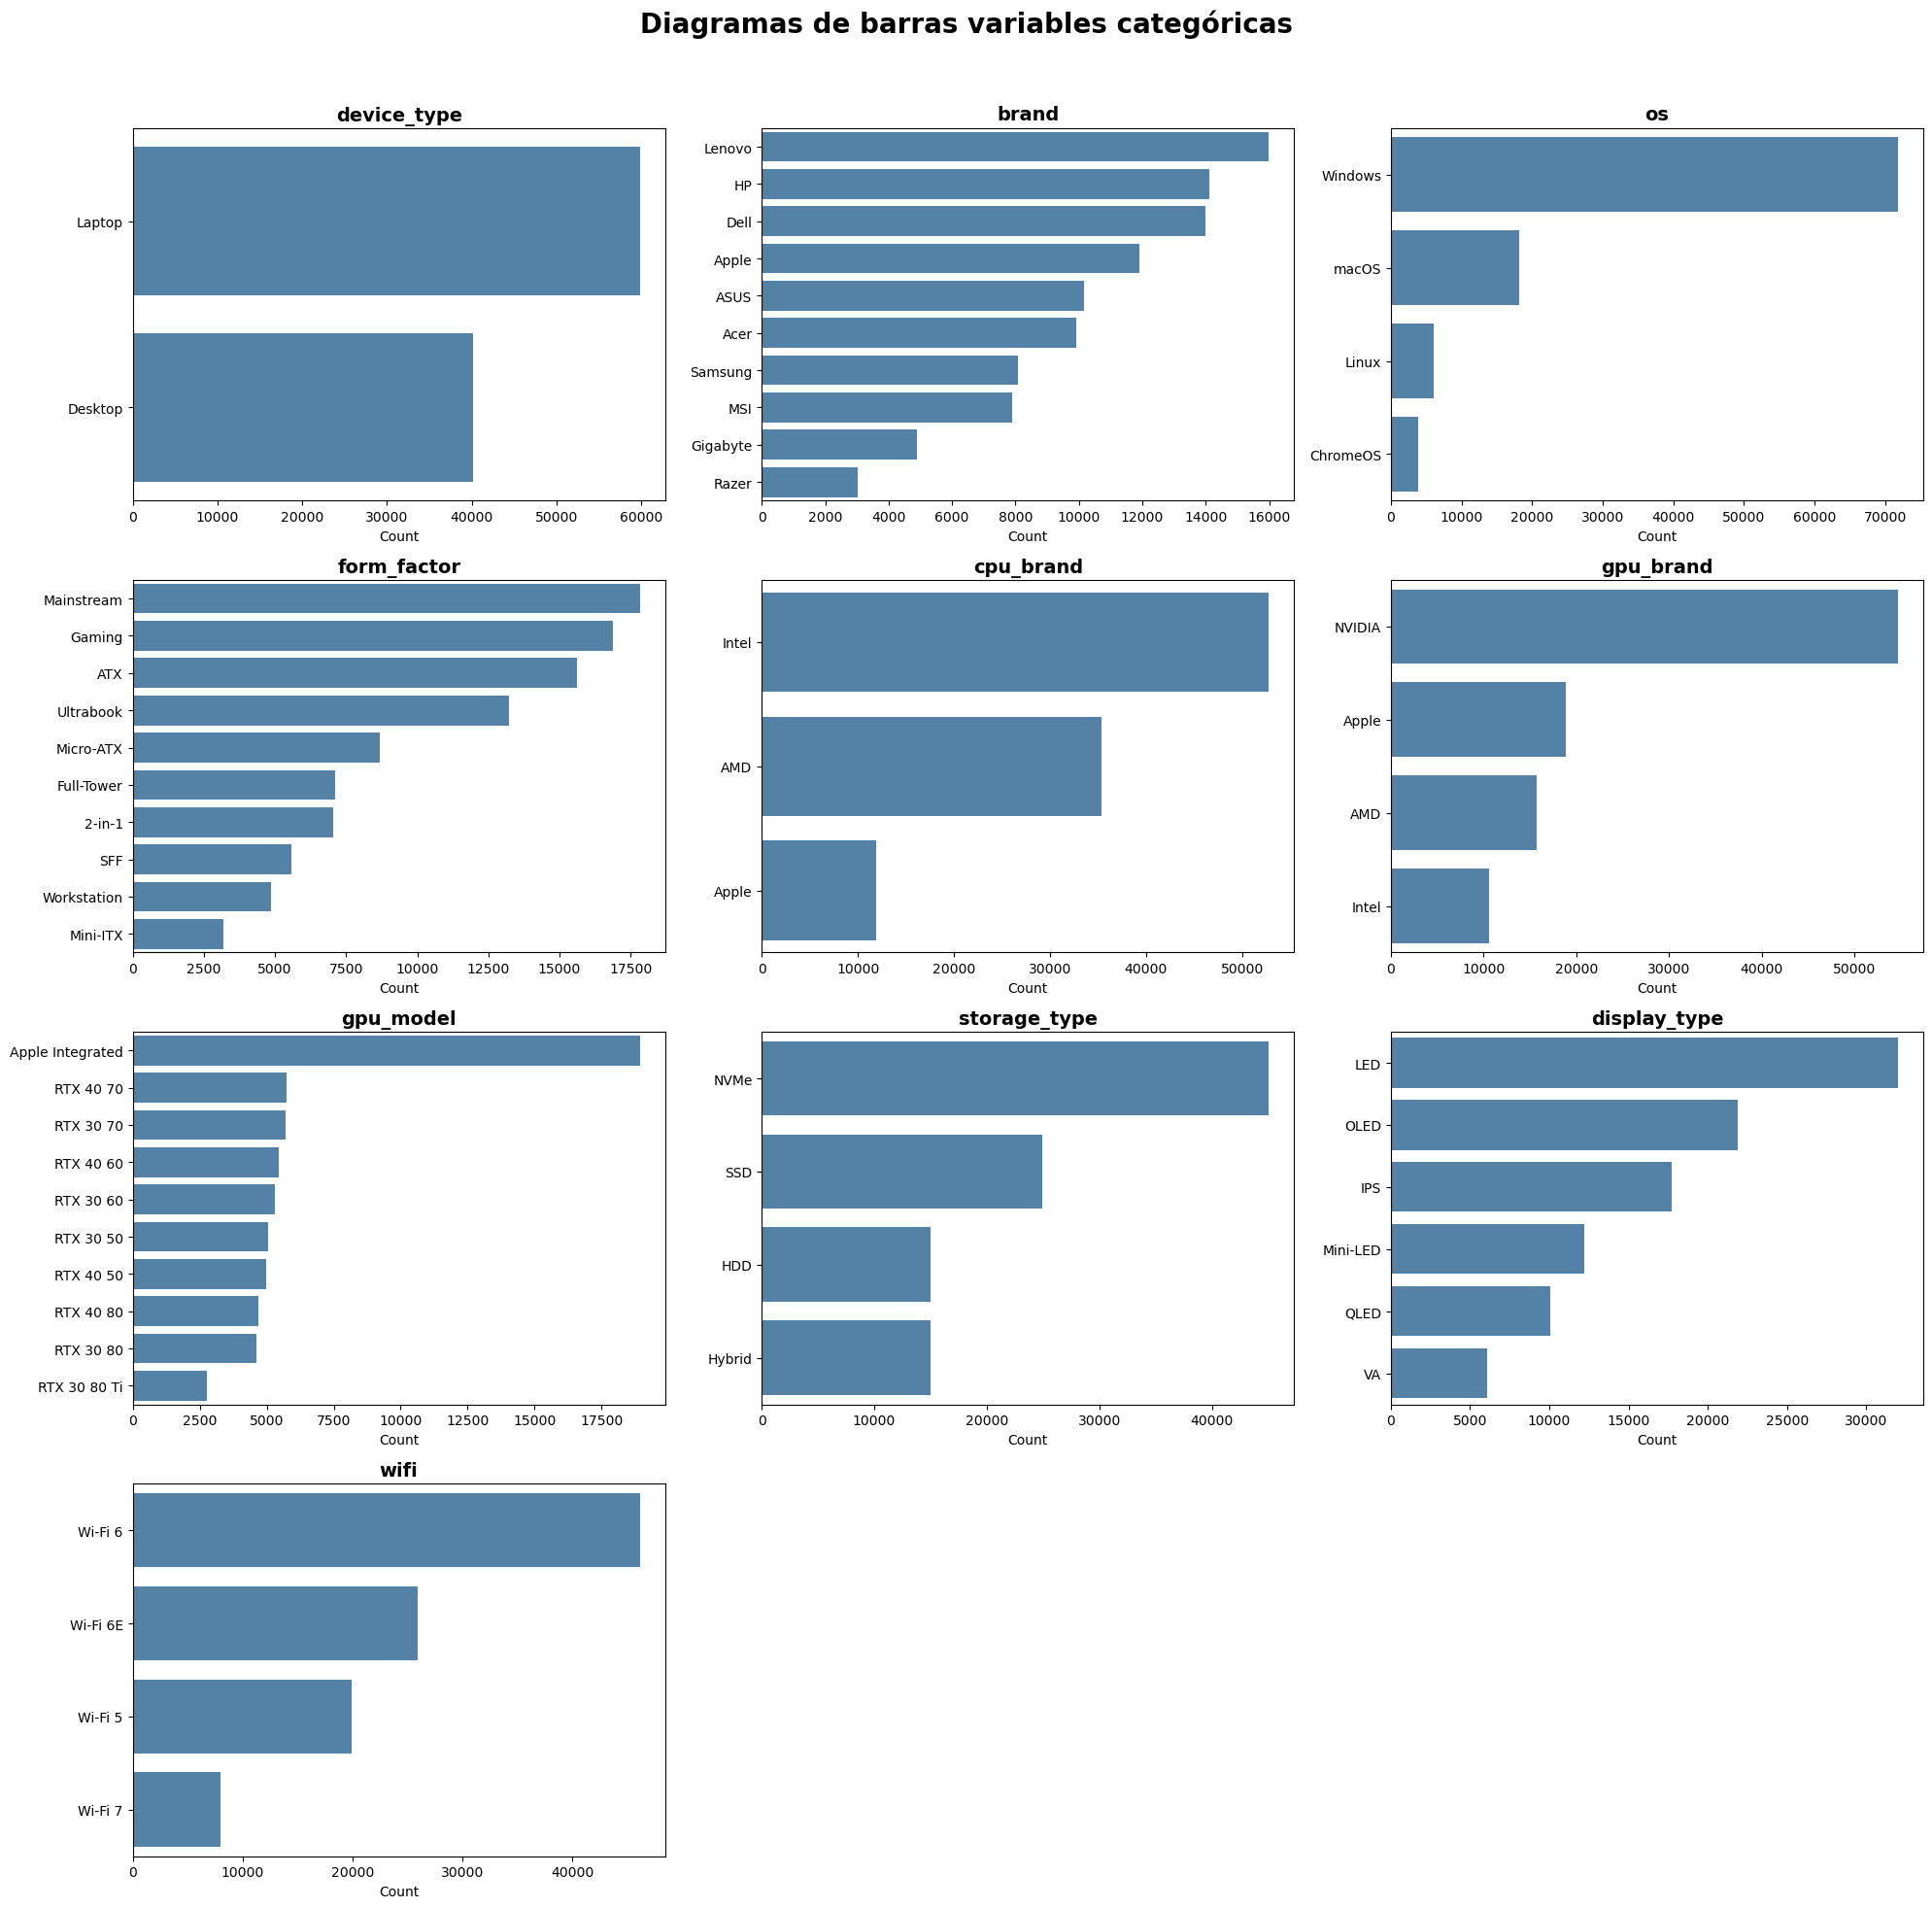

In [9]:
# Variables Numéricas
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(compu_df[col], ax=axes[i])

    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas para de variables numéricas ',
             fontsize=20,
             fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Variables categoricas 
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    if compu_df[col].nunique() > 10:
        top_10 = compu_df[col].value_counts().nlargest(10).index

        sns.countplot(
            data=compu_df[compu_df[col].isin(top_10)],
            y=col,
            order=top_10,
            color='steelblue',
            ax=axes[i]
        )
    else:
        sns.countplot(
            data=compu_df,
            y=col,
            order=compu_df[col].value_counts().index,
            color='steelblue',
            ax=axes[i]
        )

    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Diagramas de barras variables categóricas',
             fontsize=20,
             fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables, de las que se imprimieron, representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

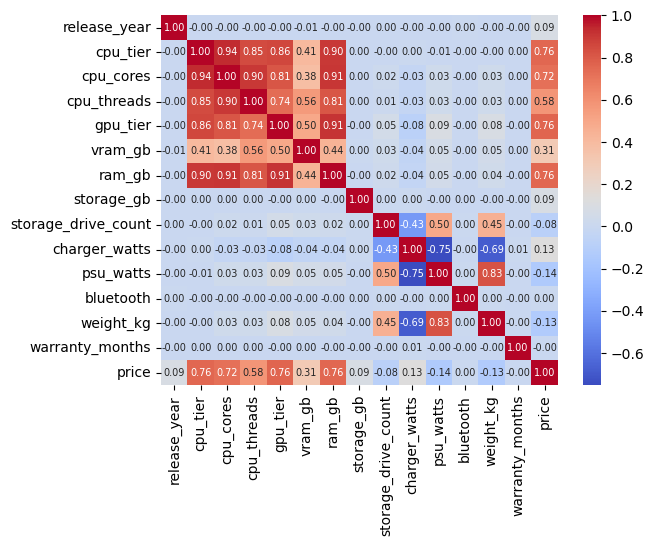

In [10]:
corr_matrix = compu_df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 7})
plt.show()



In [11]:
corr_pairs = corr_matrix.unstack()
corr_pairs[abs(corr_pairs) >= .9][abs(corr_pairs) < 1].drop_duplicates()


cpu_tier   cpu_cores    0.937376
cpu_cores  ram_gb       0.906770
gpu_tier   ram_gb       0.912918
dtype: float64

## Correlacion y seleccion de variables: 

Vemos que `cpu_cores` y `cpu_tier` tienen una correlación de r=.937. Ambas variables marcan el performance de un procesador, el primero con la cantidad de nucleos y el otro engloba en una variable ordinal la gama del 1 al 6. Claramente muestran el desempeño ya que a mayor cantidad de nucleos el procesador sera de mayor gama es por ello que se da la correlación. Por lo anterior decidimos eliminar `cpu_cores`. 

Ademas `ram_gb` y `cpu_cores` cuentan con una correlación de r=.907. Las computadoras que poseen una mayor cantidad de nucleos tienden a poseer mayor cantidad de ram, dando la correlación. 

Por ultimo  `ram_gb` y `gpu_tier` poseen una correlación de r=.913. `gpu_tieres` describe la potencía de las tarjetas graficas y observamos que existe una correlación con `ram_gb` ya que los equipos que cuentan con mayor capacidad grafica tienden a poseer más ram y mejores gpus. De las dos decidimos eliminar `ram_gb` al no tener la misma relevancía al mostrar capacidad en potencía que `gpu_tier`.

## Justificacion

 Se conservan `cpu_tier` y `gpu_tier` porque describen el desempeño de las laptops y computadoras de escritorio mediante el performance del procesador y de la GPU. Decidimos eliminar `cpu_cores` y `ram_gb` al ser información importante pero redundante al observar las correlaciones existentes en el data set para describir potencia. 

El objetivo principal es romper la alta correlación entre tres pares de variables mientras mantenemos la capacidad de describir las capacidades de cada computadora. 

In [12]:
compu_df.drop(columns=['cpu_cores', 'ram_gb'], inplace=True)
num_cols = compu_df.select_dtypes(include=np.number).columns
cat_cols = compu_df.select_dtypes(exclude=np.number).columns

4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un gráfico de barras para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

In [13]:
compu_transf = compu_df.copy()
compu_transf['years_since_release'] = date.today().year - compu_transf['release_year']
compu_transf.drop(columns=['release_year'], inplace=True)


c:\Users\mromero01\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Límites de los bins: [ 0.  4.  6.  8. 16.]


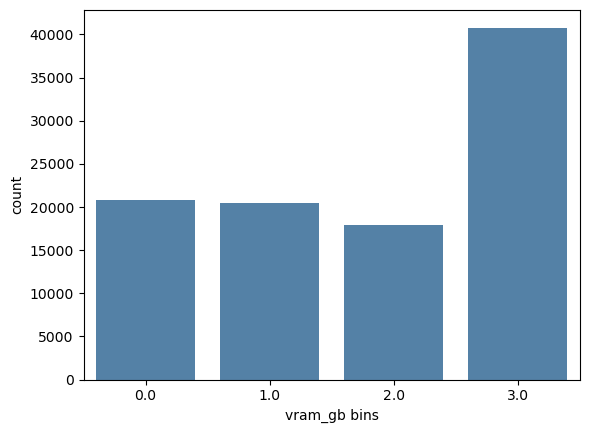

In [14]:
discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
compu_transf['vram_gb'] = discretizer.fit_transform(compu_transf[['vram_gb']])

print(f"Límites de los bins: {discretizer.bin_edges_[0]}")

sns.countplot(x='vram_gb', data=compu_transf, color='steelblue')
plt.xlabel('vram_gb bins')
plt.show()

5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [15]:
compu_df.groupby('device_type')[['charger_watts', 'psu_watts']].describe()

charger_watts                                                  \
                    count        mean        std   min   25%   50%    75%   
device_type                                                                 
Desktop           40156.0    0.000000   0.000000   0.0   0.0   0.0    0.0   
Laptop            59844.0  102.572438  48.623837  45.0  65.0  90.0  120.0   

                   psu_watts                                               \
               max     count        mean         std    min    25%    50%   
device_type                                                                 
Desktop        0.0   40156.0  678.654497  194.055038  300.0  550.0  650.0   
Laptop       240.0   59844.0    0.000000    0.000000    0.0    0.0    0.0   

                            
               75%     max  
device_type                 
Desktop      750.0  1200.0  
Laptop         0.0     0.0

Las Desktop siempre tienen **charger_watts** en 0, mientras que las Laptop siempre tienen el **psu_watts** en 0. Esto se debe a que ambas utilizan distintas fuentes de poder.

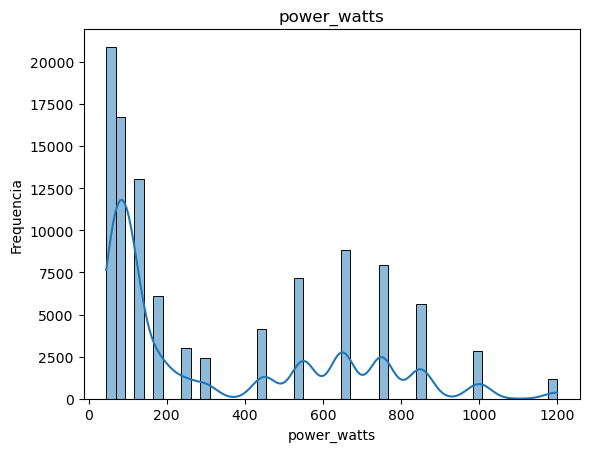

In [16]:
compu_transf['power_watts'] = compu_transf['charger_watts'] + compu_transf['psu_watts']

sns.histplot(compu_transf['power_watts'], kde=True)
plt.title('power_watts')
plt.xlabel('power_watts')
plt.ylabel('Frequencia')
plt.show()

compu_transf.drop(columns=['charger_watts', 'psu_watts'], inplace=True)

6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

In [17]:
from scipy import stats
# Tomada de Python feature engineering, agregando boxplot, outliers y skew
def diagnostic_plots(df, variable):
    plt.figure(figsize=(18,6))
    plt.subplot(1, 3, 1)
    df[variable].hist(bins=30)
    plt.title(f"Histogram of {variable}")

    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[variable])
    plt.title(f"Boxplot of {variable}")

    plt.subplot(1, 3, 3)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f"Q-Q plot of {variable}")
    plt.show()

    skewness = df[variable].skew()
    print(f"Skew: {skewness:.2f}")

    # outliers con método IQR
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[variable] < lower_bound) | (df[variable] > upper_bound)].shape[0]
    print(f"Outliers: {outliers}\n\n\n")

Price Original


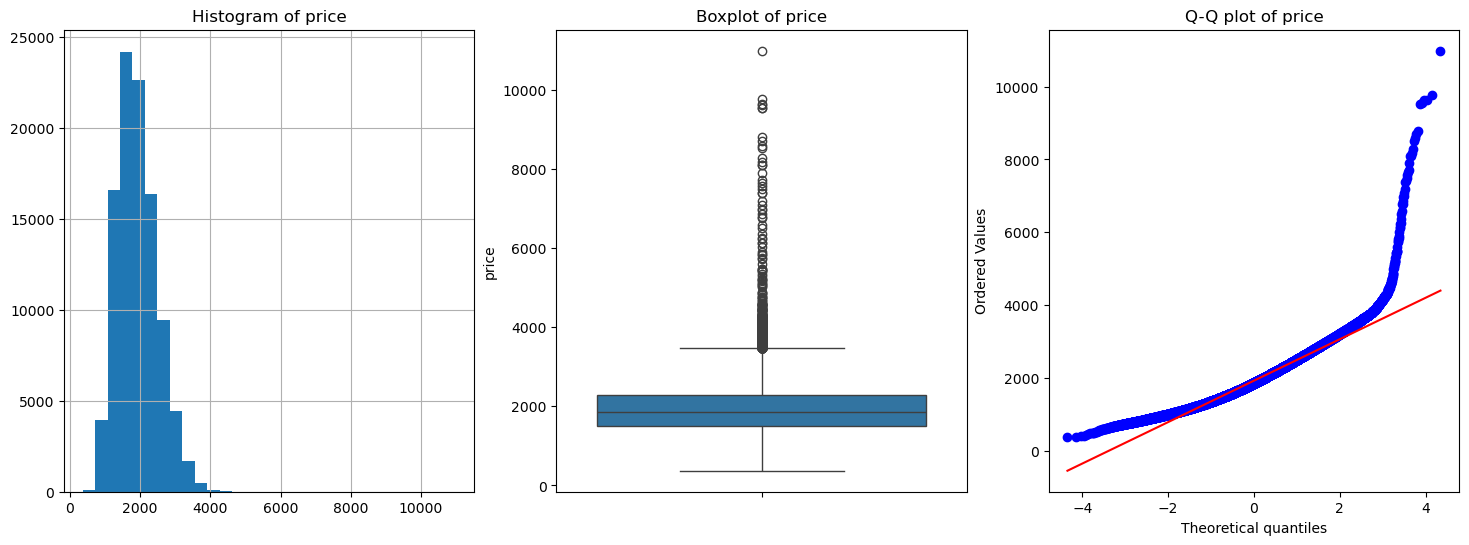

Skew: 0.99
Outliers: 976



Transformación logarítmica


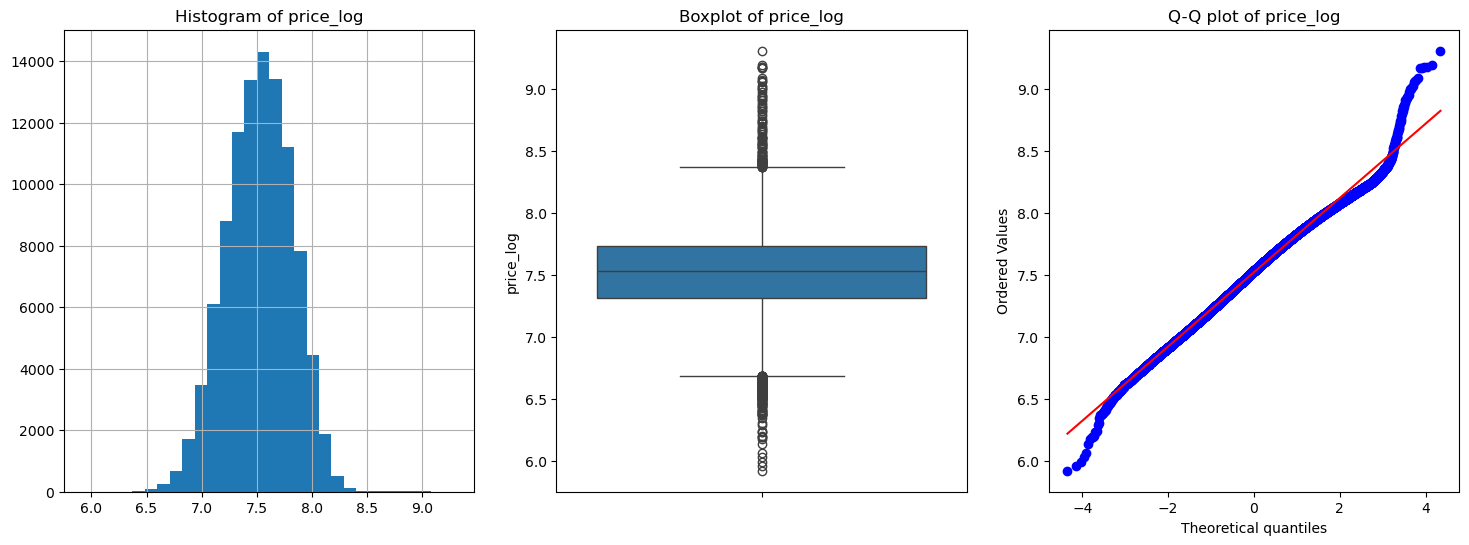

Skew: -0.13
Outliers: 386



Transformación raíz cuadrada


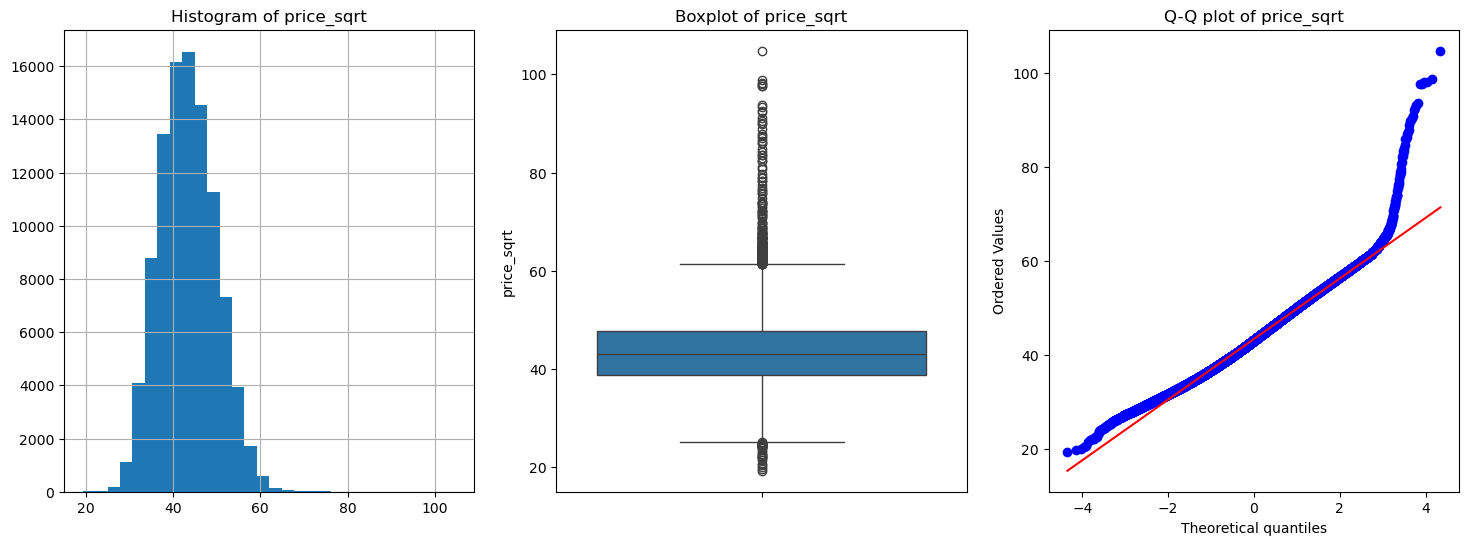

Skew: 0.33
Outliers: 364



Transformación Box-C


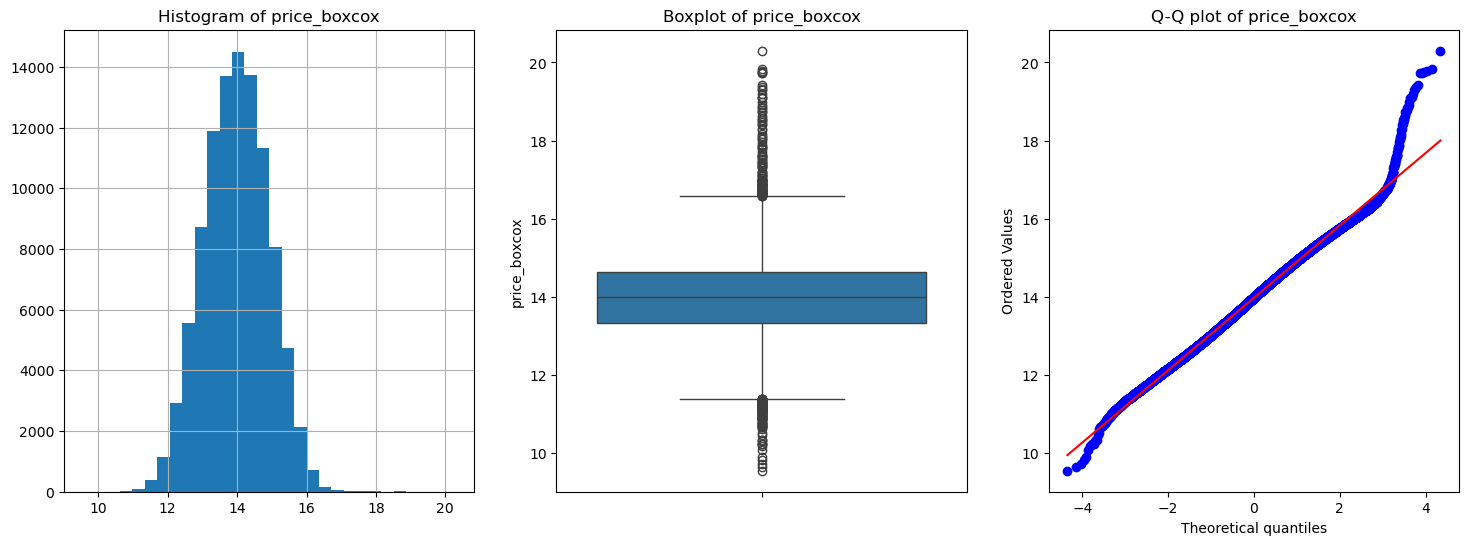

Skew: -0.00
Outliers: 317





In [18]:
log_transformer = FunctionTransformer(np.log)
sqrt_transformer = FunctionTransformer(np.sqrt)

boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
boxcox_transformer.fit(compu_transf[['price']])

price_original = compu_transf['price']
compu_transf['price_log'] = log_transformer.transform(compu_transf[['price']])
compu_transf['price_sqrt'] = sqrt_transformer.transform(compu_transf[['price']])
compu_transf['price_boxcox'] = boxcox_transformer.transform(compu_transf[['price']])

print('Price Original')
diagnostic_plots(compu_transf, 'price')
print('Transformación logarítmica')
diagnostic_plots(compu_transf, 'price_log')
print('Transformación raíz cuadrada')
diagnostic_plots(compu_transf, 'price_sqrt')
print('Transformación Box-C')
diagnostic_plots(compu_transf, 'price_boxcox')

compu_transf.drop(columns=['price_log', 'price_sqrt', 'price_boxcox'], inplace=True)


La transformación Box-Cox es la mejor, porque ajusta mejor los datos a una distribución normal, evidenciado en el q-q plot y en su sesgo de casi 0. Además reduce ligeramente la cantidad de outliers

In [19]:
boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
boxcox_transformer.fit(compu_transf[['power_watts']])
compu_transf['power_watts'] = boxcox_transformer.transform(compu_transf[['power_watts']])

boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
boxcox_transformer.fit(compu_transf[['weight_kg']])
compu_transf['weight_kg'] = boxcox_transformer.transform(compu_transf[['weight_kg']])

boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
boxcox_transformer.fit(compu_transf[['price']])
compu_transf['price'] = boxcox_transformer.transform(compu_transf[['price']])


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [20]:
num_cols_transf = compu_transf.select_dtypes(include=np.number).columns

scaler = MinMaxScaler()
compu_transf[num_cols_transf] = scaler.fit_transform(compu_transf[num_cols_transf])
display(compu_transf.head())

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,gpu_tier,...,storage_gb,storage_drive_count,display_type,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
0,Desktop,Samsung,Windows,ATX,Intel,0.4,0.384615,NVIDIA,RTX 40 60,0.2,...,0.200000,0.000000,LED,Wi-Fi 6,0.818182,0.932995,0.666667,0.328669,0.428571,0.887860
1,Laptop,Samsung,Windows,Mainstream,Intel,0.6,0.384615,NVIDIA,RTX 40 80,0.6,...,0.066667,0.000000,OLED,Wi-Fi 6,1.000000,0.423737,0.000000,0.471202,0.428571,0.357238
2,Desktop,Lenovo,macOS,SFF,AMD,0.2,0.230769,NVIDIA,RTX 40 50,0.0,...,0.066667,0.333333,LED,Wi-Fi 6,0.727273,0.834353,0.333333,0.415246,0.142857,0.918578
3,Desktop,Dell,Windows,ATX,AMD,0.2,0.153846,AMD,RX 7000 60,0.2,...,0.066667,0.333333,IPS,Wi-Fi 6,0.909091,0.795505,0.666667,0.318122,0.142857,0.851953
4,Laptop,Gigabyte,Linux,Gaming,AMD,0.8,0.538462,NVIDIA,RTX 30 80 Ti,0.8,...,0.000000,0.000000,Mini-LED,Wi-Fi 6,0.909091,0.280423,0.000000,0.520800,0.142857,0.258382


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [21]:
# 8. wifi tiene orden natural: Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7
wifi_order = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]
ordinal_encoder = OrdinalEncoder(categories=wifi_order)
compu_transf['wifi'] = ordinal_encoder.fit_transform(compu_transf[['wifi']])

# Escalar la columna codificada entre 0 y 1
compu_transf['wifi'] = MinMaxScaler().fit_transform(compu_transf[['wifi']])

print('Valores de wifi tras codificar y escalar:')
print(compu_transf['wifi'].value_counts().sort_index())

Valores de wifi tras codificar y escalar:
wifi
0.000000    19926
0.333333    46149
0.666667    25923
1.000000     8002
Name: count, dtype: int64


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [22]:
# 9. gpu_model: codificacion binaria para reducir dimensionalidad
binary_encoder = BinaryEncoder(cols=['gpu_model'])
bin_df = binary_encoder.fit_transform(compu_transf['gpu_model'])
bin_df.head()
print('Dimensiones de bin_df:', bin_df.shape)
display(bin_df.head())

Dimensiones de bin_df: (100000, 6)


,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [24]:
# 10. OneHotEncoder para las categoricas restantes (drop='first')
remaining_cat = compu_transf.select_dtypes(exclude = 'number').columns.drop('gpu_model').tolist()
print('Categoricas a codificar con One-Hot:', remaining_cat)

ohe = OneHotEncoder(drop='first', sparse_output=False) #<- para versiones más nuevas 
# ohe = OneHotEncoder(drop='first', sparse=False)          # para versiones más viejas 
ohe_array = ohe.fit_transform(compu_transf[remaining_cat])
ohe_df = pd.DataFrame(ohe_array,
                      columns=ohe.get_feature_names_out(remaining_cat),
                      index=compu_transf.index)

# Eliminar las variables originales (categoricas + gpu_model)
compu_transf = compu_transf.drop(columns=remaining_cat + ['gpu_model'])

# Combinar compu_transf con las variables codificadas
compu_transf = pd.concat(
    [compu_transf.reset_index(drop=True),
     bin_df.reset_index(drop=True),
     ohe_df.reset_index(drop=True)],
    axis=1)

Categoricas a codificar con One-Hot: ['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'storage_type', 'display_type']


In [ ]:
print('\nShape final:', compu_transf.shape)
print('Columnas categoricas sin codificar:', compu_transf.select_dtypes(exclude='number').shape[1])
display(compu_transf.describe().T)


Shape final: (100000, 54)
Columnas categoricas sin codificar: 0


,count,mean,std,min,25%,50%,75%,max
cpu_tier,100000.0,0.430698,0.274635,0.0,0.200000,0.400000,0.600000,1.0
cpu_threads,100000.0,0.295629,0.186893,0.0,0.153846,0.230769,0.384615,1.0
gpu_tier,100000.0,0.398270,0.291929,0.0,0.200000,0.400000,0.600000,1.0
vram_gb,100000.0,0.595883,0.394170,0.0,0.333333,0.666667,1.000000,1.0
storage_gb,100000.0,0.168733,0.201626,0.0,0.066667,0.066667,0.200000,1.0
storage_drive_count,100000.0,0.174993,0.265761,0.0,0.000000,0.000000,0.333333,1.0
wifi,100000.0,0.406670,0.284834,0.0,0.333333,0.333333,0.666667,1.0
bluetooth,100000.0,0.804331,0.223616,0.0,0.727273,0.818182,0.909091,1.0
weight_kg,100000.0,0.517032,0.293982,0.0,0.280423,0.417162,0.834353,1.0
warranty_months,100000.0,0.283343,0.284219,0.0,0.000000,0.333333,0.333333,1.0


---

**Declaración de uso de IA**

* Anthropic. (2026). Claude (Opus 4) [Modelo de lenguaje grande], utilizado para revisión, depuración y optimización del código de la libreta. https://claude.ai/

---